     Release_Date                                 Title  \
0      2021-12-15               Spider-Man: No Way Home   
1      2022-03-01                            The Batman   
2      2022-02-25                               No Exit   
3      2021-11-24                               Encanto   
4      2021-12-22                        The King's Man   
...           ...                                   ...   
9832   1973-10-15                              Badlands   
9833   2020-10-01                      Violent Delights   
9834   2016-05-06                          The Offering   
9835   2021-03-31  The United States vs. Billie Holiday   
9836   1984-09-23                               Threads   

                                               Overview  Popularity  \
0     Peter Parker is unmasked and no longer able to...    5083.954   
1     In his second year of fighting crime, Batman u...    3827.658   
2     Stranded at a rest stop in the mountains durin...    2618.087   
3     T

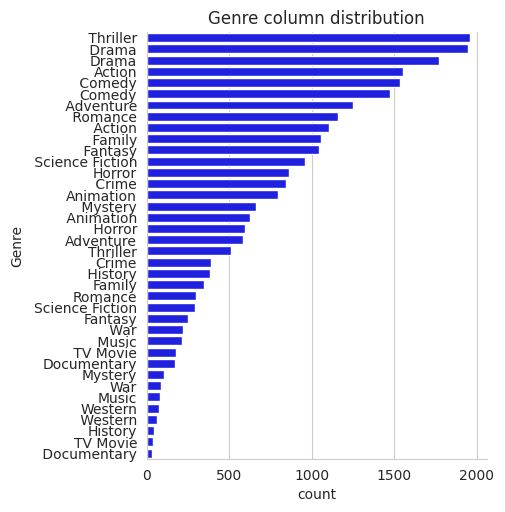

   Release_Date                    Title  Popularity Vote_Count Vote_Average  \
0        2021.0  Spider-Man: No Way Home    5083.954       8940      popular   
1        2021.0  Spider-Man: No Way Home    5083.954       8940      popular   
2        2021.0  Spider-Man: No Way Home    5083.954       8940      popular   

              Genre  
0            Action  
1         Adventure  
2   Science Fiction  
       Release_Date                                 Title  Popularity  \
25545        2021.0  The United States vs. Billie Holiday      13.354   
25546        2021.0  The United States vs. Billie Holiday      13.354   
25547        2021.0  The United States vs. Billie Holiday      13.354   
25548        1984.0                               Threads      13.354   
25549        1984.0                               Threads      13.354   
25550        1984.0                               Threads      13.354   

      Vote_Count Vote_Average             Genre  
25545        152      average

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/content/mymoviedb.csv', engine='python', on_bad_lines='skip')
print(df)
df.head()
df.info()
print(df['Genre'].head())
print(df.duplicated().sum())
print(df.describe())


# we have a dataframe consisting of 9827 rows and 9 columns.
# our dataset looks a bit tidy with no NaNs nor duplicate value.
# Realse _Data Column needs to be casted into data time and to extract only the year value.
# Overview,original_language and poster-Url wouldn't be as usefull during analysis ,so we'll drop them.
# there is noticable outerliers in popularity column.
# vote_Average better be categorised for proper analysis.
# Genere column has comma seperated values and white spaces that needs to be handled and castes into category.Exloratory summmary.


In [ ]:
df['Release_Date']=pd.to_datetime(df['Release_Date'], errors='coerce')
print(df['Release_Date'].dtype)

df['Release_Date']=df['Release_Date'].dt.year
print(df['Release_Date'].dtype)

print(df.head())


# Dropping the columns

In [ ]:
cols=['Overview','Original_Language','Poster_Url']
print(df.drop(cols,axis=1,inplace=True))

# Convert 'Vote_Average' to numeric, coercing errors to NaN

In [ ]:

df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

# catogorizing vote_Average columns
# user_defined function

In [ ]:

def catigorize_col(df,col,labels):
    edges=[df[col].describe()['min'],
           df[col].describe()['25%'],
           df[col].describe()['50%'],
           df[col].describe()['75%'],
           df[col].describe()['max']]
    df[col]=pd.cut(df[col],edges,labels=labels,duplicates='drop')
    return df

labels=['not-popular','below_average','average','popular']
catigorize_col(df,'Vote_Average',labels)
print(df['Vote_Average'].unique())

print(df.head())

print(df['Vote_Average'].value_counts())

df.dropna(inplace=True)

print(df.isna().sum())

print(df.head())


# we'd split genres into a list and then explode our dataframe to have only one genre per row of each movie

In [ ]:
df['Genre']=df['Genre'].str.split(',')
df=df.explode('Genre').reset_index(drop=True)
print(df.head())

# casting column into category



In [ ]:
df['Genre']=df['Genre'].astype('category')
print(df['Genre'].dtype)
df.info()
print(df.nunique())

print(df.head())

# Data visulaziation

In [ ]:

sns.set_style(('whitegrid'))


# what is the most frequent genre of movie releases on Netflix?

In [ ]:
print(df['Genre'].describe())

sns.catplot(y='Genre',data=df,kind='count',order=df['Genre'].value_counts().index,color='blue')

plt.title("Genre column distribution")
plt.show()

# which has highest votes in vote average column?

In [ ]:
sns.catplot(y='Vote_Average',data=df,kind='count',order=df['Vote_Average'].value_counts().index,color='pink')
plt.title('Vote distribution')
plt.show()

# what movie got the highest popularity?what's its genre?

In [ ]:
print(df[df['Popularity']==df['Popularity'].max()])



# what movie got the lowest popularity?what's its genre?

In [ ]:

print(df[df['Popularity']==df['Popularity'].min()])


# which year has the most flimmed movie?


In [ ]:
df['Release_Date'].hist()
plt.title('Release Date column distribution')
plt.show()